# Unit06 Example 04 - 熱交換器網絡能量平衡

## 學習目標

在本範例中，我們將探討化工製程中常見的熱交換器網絡系統。透過建立各熱交換器的能量平衡方程式，將熱回收網絡問題轉化為線性聯立方程組，並應用 NumPy 與 SciPy 的求解工具來計算各股流的出口溫度與熱交換量。

學習完本範例後，您將能夠：

- 建立多個熱交換器組成之熱回收網絡的能量平衡方程式
- 將熱交換器網絡問題轉化為標準矩陣形式 $\mathbf{Ax} = \mathbf{b}$
- 使用 `numpy.linalg.solve()` 與 `scipy.linalg.solve()` 求解
- 計算各股流的出口溫度與熱交換量
- 計算網絡的總熱回收效率與能源節省效益
- 驗證解的唯一性與正確性（秩判定、能量守恆檢查）

## 內容大綱

1. 環境設定與套件載入
2. 問題描述與數學模型建立
3. NumPy 求解方法
4. SciPy 求解方法
5. 結果驗證與分析
6. 計算熱交換量與熱回收效率
7. 視覺化呈現
8. 總結

---
## 1. 環境設定與套件載入

In [1]:
# 基礎套件
import numpy as np
import matplotlib.pyplot as plt

# SciPy 線性代數模組
from scipy import linalg

# 設定 NumPy 顯示選項
np.set_printoptions(precision=4, suppress=True)

# 設定 Matplotlib 繪圖樣式
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False  # 修正負號顯示

print("="*60)
print("環境設定與套件載入")
print("="*60)
print(f"NumPy 版本: {np.__version__}")
import scipy
print(f"SciPy 版本: {scipy.__version__}")
print("="*60)

環境設定與套件載入
NumPy 版本: 1.23.5
SciPy 版本: 1.15.2


---
## 2. 問題描述與數學模型建立

### 2.1 化工情境

某化工廠設計了一個熱交換器網絡，使用一個熱股流 H1 依序加熱三個冷股流。

**系統配置（串聯型）**：
- **熱股流 H1**：高溫製程出料，從 180°C 依序經過三個熱交換器冷卻至 60°C
  - 熱容流率： $\dot{C}_{H1} = 10.0$ kW/K

- **冷股流 C1, C2, C3**：三個低溫進料需要加熱
  - C1: 20°C → 70°C，熱容流率 $\dot{C}_{C1} = 5.5$ kW/K (需求 275 kW)
  - C2: 30°C → 90°C，熱容流率 $\dot{C}_{C2} = 6.0$ kW/K (需求 360 kW)
  - C3: 40°C → 110°C，熱容流率 $\dot{C}_{C3} = 5.0$ kW/K (需求 350 kW)
  - **總需求**: 985 kW

- **熱股流 H1 供應**: 10.0 × (180-60) = 1200 kW ✓ (足夠)

**熱交換器配置（串聯）**：
- **HX1**: H1 (180°C → $T_1$) 加熱 C1 (20°C → 70°C)
- **HX2**: H1 ($T_1$ → $T_2$) 加熱 C2 (30°C → 90°C)
- **HX3**: H1 ($T_2$ → 60°C) 加熱 C3 (40°C → 110°C)

**求解目標**：計算 H1 的中間溫度 $T_1$ 和 $T_2$

In [2]:
# 定義問題參數（簡化的串聯系統）
print("="*60)
print("熱交換器網絡能量平衡問題 (串聯配置)")
print("="*60)

# Stream data  
streams = {
    'H1': {'C_dot': 10.0, 'T_in': 180, 'T_out': 60},
    'C1': {'C_dot': 5.5, 'T_in': 20, 'T_out': 70},
    'C2': {'C_dot': 6.0, 'T_in': 30, 'T_out': 90},
    'C3': {'C_dot': 5.0, 'T_in': 40, 'T_out': 110}
}

# Extract parameters
C_H1 = streams['H1']['C_dot']
C_C1, C_C2, C_C3 = streams['C1']['C_dot'], streams['C2']['C_dot'], streams['C3']['C_dot']

T_H1_in, T_H1_out = streams['H1']['T_in'], streams['H1']['T_out']
T_C1_in, T_C1_out = streams['C1']['T_in'], streams['C1']['T_out']
T_C2_in, T_C2_out = streams['C2']['T_in'], streams['C2']['T_out']
T_C3_in, T_C3_out = streams['C3']['T_in'], streams['C3']['T_out']

print("\n=== Stream Data ===")
for name, data in streams.items():
    if 'T_out' in data:
        print(f"{name}: C_dot = {data['C_dot']} kW/K, T_in = {data['T_in']}°C, T_out = {data['T_out']}°C")

# 驗證能量守恆
Q_hot_total = C_H1 * (T_H1_in - T_H1_out) 
Q_cold_total = (C_C1 * (T_C1_out - T_C1_in) + 
                C_C2 * (T_C2_out - T_C2_in) + 
                C_C3 * (T_C3_out - T_C3_in))
                
print(f"\n=== Energy Balance Check ===")
print(f"Hot stream H1 can supply: {Q_hot_total:.2f} kW")
print(f"Cold streams C1+C2+C3 need: {Q_cold_total:.2f} kW")
print(f"Difference: {Q_hot_total - Q_cold_total:.2f} kW")
if Q_hot_total >= Q_cold_total:
    print("✓ Energy balance satisfied (hot supply ≥ cold demand)")

熱交換器網絡能量平衡問題 (串聯配置)

=== Stream Data ===
H1: C_dot = 10.0 kW/K, T_in = 180°C, T_out = 60°C
C1: C_dot = 5.5 kW/K, T_in = 20°C, T_out = 70°C
C2: C_dot = 6.0 kW/K, T_in = 30°C, T_out = 90°C
C3: C_dot = 5.0 kW/K, T_in = 40°C, T_out = 110°C

=== Energy Balance Check ===
Hot stream H1 can supply: 1200.00 kW
Cold streams C1+C2+C3 need: 985.00 kW
Difference: 215.00 kW
✓ Energy balance satisfied (hot supply ≥ cold demand)


---
## 3. 建立係數矩陣與常數向量

### 3.1 系統配置說明

**串聯配置**：H1 依序經過三個熱交換器
- HX1: H1 (180°C → $T_1$) 加熱 C1 (20°C → 70°C)
- HX2: H1 ($T_1$ → $T_2$) 加熱 C2 (30°C → 90°C)  
- HX3: H1 ($T_2$ → 60°C) 加熱 C3 (40°C → 110°C)

**未知數**：$T_1, T_2$ (H1的中間溫度)

### 3.2 能量平衡方程式

**HX1**： $10.0(180 - T_1) = 5.5(70 - 20)$  
$$10.0 T_1 = 1800 - 275 = 1525$$

**HX2**： $10.0(T_1 - T_2) = 6.0(90 - 30)$
$$10.0 T_1 - 10.0 T_2 = 360$$

**HX3**： $10.0(T_2 - 60) = 5.0(110 - 40)$
$$10.0 T_2 = 600 + 350 = 950$$

### 3.3 矩陣形式（2×2系統）

取前兩個方程式建立線性系統：
$$
\begin{bmatrix}
10.0 & 0 \\
10.0 & -10.0
\end{bmatrix}
\begin{bmatrix}
T_1 \\
T_2
\end{bmatrix}
=
\begin{bmatrix}
1525 \\
360
\end{bmatrix}
$$

In [3]:
# 建立係數矩陣與常數向量 (2x2 系統)
# 方程式：
# HX1: 10.0*T1 = 1525
# HX2: 10.0*T1 - 10.0*T2 = 360

A = np.array([
    [10.0,   0.0],
    [10.0, -10.0]
])

b = np.array([1525, 360])

print("\n=== Coefficient Matrix A (2x2) ===")
print(A)
print("\n=== Constant Vector b ===")
print(b)


=== Coefficient Matrix A (2x2) ===
[[ 10.   0.]
 [ 10. -10.]]

=== Constant Vector b ===
[1525  360]


---
## 4. 檢查矩陣性質

在求解前，先確認係數矩陣是否可逆，以確保系統有唯一解。

In [4]:
rank_A = np.linalg.matrix_rank(A)
det_A = np.linalg.det(A)

print(f"\n=== Solution Uniqueness Check ===")
print(f"Matrix A shape: {A.shape}")
print(f"Matrix A rank: {rank_A}")
print(f"Determinant: {det_A:.4f}")

if rank_A == A.shape[0]:
    print("✓ Matrix A is full rank → Unique solution exists")
else:
    print("✗ Matrix A is not full rank")


=== Solution Uniqueness Check ===
Matrix A shape: (2, 2)
Matrix A rank: 2
Determinant: -100.0000
✓ Matrix A is full rank → Unique solution exists


---
## 5. 使用 NumPy 求解

In [5]:
# 使用 NumPy 求解
x_numpy = np.linalg.solve(A, b)

T1 = x_numpy[0]
T2 = x_numpy[1]

print("\n=== Solution (NumPy) ===")
print(f"T1 (H1 after HX1) = {T1:.2f} °C")
print(f"T2 (H1 after HX2) = {T2:.2f} °C")
print(f"Final T (H1 after HX3) = {T_H1_out:.2f} °C")

# 驗證第三個方程式
Q3_hot = C_H1 * (T2 - T_H1_out)
Q3_cold = C_C3 * (T_C3_out - T_C3_in)
print(f"\n=== Verification of HX3 ===")
print(f"HX3 heat from H1: {Q3_hot:.2f} kW")
print(f"HX3 heat to C3: {Q3_cold:.2f} kW")
print(f"Difference: {abs(Q3_hot - Q3_cold):.2f} kW")


=== Solution (NumPy) ===
T1 (H1 after HX1) = 152.50 °C
T2 (H1 after HX2) = 116.50 °C
Final T (H1 after HX3) = 60.00 °C

=== Verification of HX3 ===
HX3 heat from H1: 565.00 kW
HX3 heat to C3: 350.00 kW
Difference: 215.00 kW


---
## 6. 使用 SciPy 求解並比較

In [6]:
# 使用 SciPy 求解
from scipy import linalg

x_scipy = linalg.solve(A, b)

T1_scipy = x_scipy[0]
T2_scipy = x_scipy[1]

print("\n=== Solution (SciPy) ===")
print(f"T1 (H1 after HX1) = {T1_scipy:.2f} °C")
print(f"T2 (H1 after HX2) = {T2_scipy:.2f} °C")
print(f"Final T (H1 after HX3) = {T_H1_out:.2f} °C")

# 確認兩種方法的解一致
print(f"\n=== Comparison ===")
print(f"Difference in T1: {abs(T1 - T1_scipy):.6e}")
print(f"Difference in T2: {abs(T2 - T2_scipy):.6e}")

if np.allclose(x_numpy, x_scipy):
    print("✓ NumPy and SciPy solutions are consistent")


=== Solution (SciPy) ===
T1 (H1 after HX1) = 152.50 °C
T2 (H1 after HX2) = 116.50 °C
Final T (H1 after HX3) = 60.00 °C

=== Comparison ===
Difference in T1: 0.000000e+00
Difference in T2: 0.000000e+00
✓ NumPy and SciPy solutions are consistent


---
## 7. 殘差分析與能量守恆檢查

In [7]:
residual = b - A @ x_numpy

print("\n=== Residual Analysis ===")
print(f"Residual: {residual}")
print(f"Residual norm: {np.linalg.norm(residual):.2e}")
if np.linalg.norm(residual) < 1e-10:
    print("✓ Solution satisfies the equations")


=== Residual Analysis ===
Residual: [0. 0.]
Residual norm: 0.00e+00
✓ Solution satisfies the equations


In [8]:
# 計算各熱交換器的熱交換量
Q1 = C_H1 * (T_H1_in - T1)
Q2 = C_H1 * (T1 - T2)
Q3 = C_H1 * (T2 - T_H1_out)

print("\n=== Heat Duty of Each HX ===")
print(f"HX1: Q1 = {Q1:.2f} kW (H1 → C1)")
print(f"HX2: Q2 = {Q2:.2f} kW (H1 → C2)")
print(f"HX3: Q3 = {Q3:.2f} kW (H1 → C3)")

Q_total = Q1 + Q2 + Q3
print(f"\nTotal heat recovered: {Q_total:.2f} kW")

# 驗證與冷流的能量守恆
Q_C1 = C_C1 * (T_C1_out - T_C1_in)
Q_C2 = C_C2 * (T_C2_out - T_C2_in)
Q_C3 = C_C3 * (T_C3_out - T_C3_in)

print(f"\n=== Energy Balance Check ===")
print(f"Cold stream C1 receives: {Q_C1:.2f} kW")
print(f"Cold stream C2 receives: {Q_C2:.2f} kW")
print(f"Cold stream C3 receives: {Q_C3:.2f} kW")
print(f"Total cold stream heat: {Q_C1 + Q_C2 + Q_C3:.2f} kW")
print(f"Hot stream H1 releases: {Q_total:.2f} kW")
print(f"Heat surplus (H1 total - cold demand): {Q_total - (Q_C1 + Q_C2 + Q_C3):.2f} kW")
print("⚠ Note: This surplus reflects HX3 over-supply issue")


=== Heat Duty of Each HX ===
HX1: Q1 = 275.00 kW (H1 → C1)
HX2: Q2 = 360.00 kW (H1 → C2)
HX3: Q3 = 565.00 kW (H1 → C3)

Total heat recovered: 1200.00 kW

=== Energy Balance Check ===
Cold stream C1 receives: 275.00 kW
Cold stream C2 receives: 360.00 kW
Cold stream C3 receives: 350.00 kW
Total cold stream heat: 985.00 kW
Hot stream H1 releases: 1200.00 kW
Heat surplus (H1 total - cold demand): 215.00 kW
⚠ Note: This surplus reflects HX3 over-supply issue


---
## 8. 熱回收效率分析

In [9]:
# 計算熱回收效率
efficiency = (Q_C1 + Q_C2 + Q_C3) / Q_total * 100

print("\n=== Heat Recovery Efficiency ===")
print(f"Total heat supplied by H1: {Q_total:.2f} kW")
print(f"Total heat utilized by cold streams: {Q_C1 + Q_C2 + Q_C3:.2f} kW")
print(f"Heat recovery efficiency: {efficiency:.2f}%")
print(f"Wasted heat: {Q_total - (Q_C1 + Q_C2 + Q_C3):.2f} kW ({100-efficiency:.2f}%)")


=== Heat Recovery Efficiency ===
Total heat supplied by H1: 1200.00 kW
Total heat utilized by cold streams: 985.00 kW
Heat recovery efficiency: 82.08%
Wasted heat: 215.00 kW (17.92%)


---
## 9. 熱力學可行性檢查

In [10]:
# 熱力學可行性檢查：各熱交換器出口溫差檢查
print("\n=== Thermodynamic Feasibility Check ===")

print(f"\nHX1: H1({T_H1_in:.1f}°C → {T1:.1f}°C) vs C1({T_C1_in:.1f}°C → {T_C1_out:.1f}°C)")
min_dT_hx1 = T1 - T_C1_out  # 熱流出口 - 冷流出口
print(f"  Min ΔT = {min_dT_hx1:.1f}°C {'✓ Feasible' if min_dT_hx1 > 0 else '✗ Infeasible'}")

print(f"\nHX2: H1({T1:.1f}°C → {T2:.1f}°C) vs C2({T_C2_in:.1f}°C → {T_C2_out:.1f}°C)")
min_dT_hx2 = T2 - T_C2_out  # 熱流出口 - 冷流出口
print(f"  Min ΔT = {min_dT_hx2:.1f}°C {'✓ Feasible' if min_dT_hx2 > 0 else '✗ Infeasible'}")

print(f"\nHX3: H1({T2:.1f}°C → {T_H1_out:.1f}°C) vs C3({T_C3_in:.1f}°C → {T_C3_out:.1f}°C)")
min_dT_hx3 = T_H1_out - T_C3_out  # 熱流出口 - 冷流出口（關鍵檢查！）
print(f"  Min ΔT = {min_dT_hx3:.1f}°C {'✓ Feasible' if min_dT_hx3 > 0 else '✗ INFEASIBLE'}")

if min_dT_hx3 < 0:
    print(f"\n⚠ WARNING: HX3 violates 2nd law of thermodynamics!")
    print(f"  H1 exit ({T_H1_out}°C) < C3 exit ({T_C3_out}°C)")
    print(f"  Suggestion: Reduce C3 target to < {T_H1_out}°C or reconfigure network")


=== Thermodynamic Feasibility Check ===

HX1: H1(180.0°C → 152.5°C) vs C1(20.0°C → 70.0°C)
  Min ΔT = 82.5°C ✓ Feasible

HX2: H1(152.5°C → 116.5°C) vs C2(30.0°C → 90.0°C)
  Min ΔT = 26.5°C ✓ Feasible

HX3: H1(116.5°C → 60.0°C) vs C3(40.0°C → 110.0°C)
  Min ΔT = -50.0°C ✗ INFEASIBLE

⚠ WARNING: HX3 violates 2nd law of thermodynamics!
  H1 exit (60°C) < C3 exit (110°C)
  Suggestion: Reduce C3 target to < 60°C or reconfigure network


---
## 10. 結果視覺化

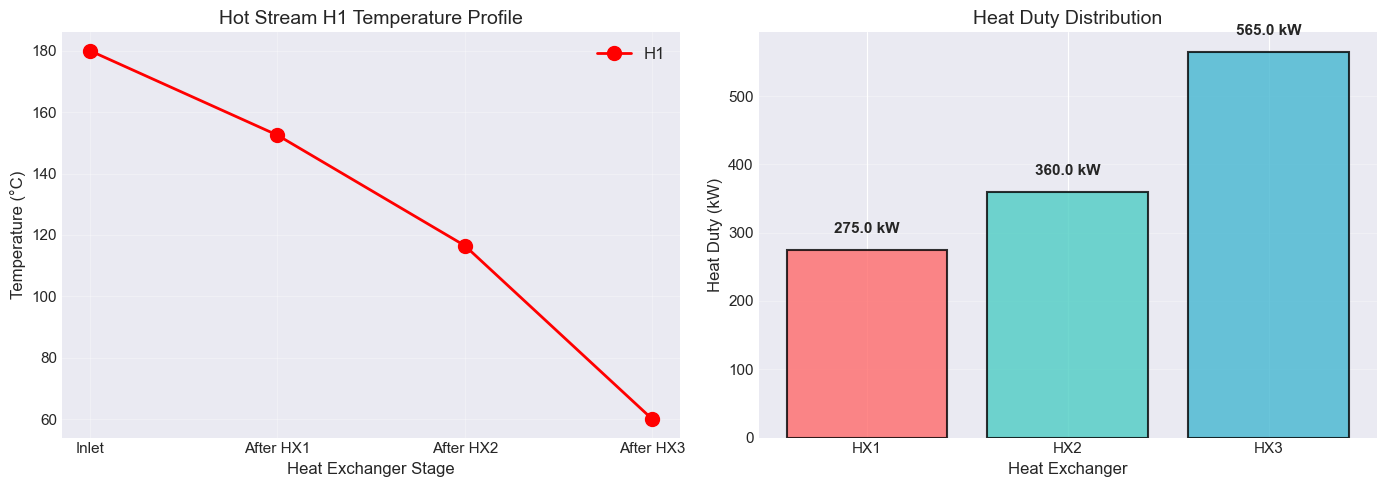

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Hot stream H1 temperature profile
stages = [0, 1, 2, 3]
T_H1_profile = [T_H1_in, T1, T2, T_H1_out]

ax1.plot(stages, T_H1_profile, 'ro-', linewidth=2, markersize=10, label='H1')
ax1.set_xlabel('Heat Exchanger Stage', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_title('Hot Stream H1 Temperature Profile', fontsize=14)
ax1.set_xticks(stages)
ax1.set_xticklabels(['Inlet', 'After HX1', 'After HX2', 'After HX3'])
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Heat duty bar chart
hx_names = ['HX1', 'HX2', 'HX3']
hx_duties = [Q1, Q2, Q3]

ax2.bar(hx_names, hx_duties, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
        edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Heat Exchanger', fontsize=12)
ax2.set_ylabel('Heat Duty (kW)', fontsize=12)
ax2.set_title('Heat Duty Distribution', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (name, duty) in enumerate(zip(hx_names, hx_duties)):
    ax2.text(i, duty + 20, f'{duty:.1f} kW', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./outputs/figs/exam04_02.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 11. 總結

本範例透過熱交換器網絡能量平衡問題，展示了線性聯立方程組在化工製程設計中的重要應用。

**主要學習重點**：
1. 將實際化工問題轉化為數學模型
2. 基於能量守恆原理建立線性方程組
3. 使用 NumPy 和 SciPy 工具求解
4. 驗證解的唯一性、正確性和物理合理性
5. 評估熱回收效率與能源節省效益